## Part 3 — Strategy Recommendations

This notebook builds on Part 1 (data preparation) and Part 2 (performance analysis) to
turn the findings into two concrete, data-backed strategy recommendations.

It picks up the `merged` account-day table and the `trader_type` / `consistency_type`
segments defined in Part 2, so it can run independently.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "font.family": "DejaVu Sans"
})

# Load raw data
df = pd.read_csv('historical_data.csv')
df_sentiment = pd.read_csv('fear_greed_index.csv')

# Clean timestamps
df['Timestamp IST'] = pd.to_datetime(df['Timestamp IST'], format='%d-%m-%Y %H:%M')
df['date'] = df['Timestamp IST'].dt.date
df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.date

# Helper columns
df['is_win'] = df['Closed PnL'] > 0
df['is_long'] = df['Side'] == 'BUY'

# Aggregate to account-day level
daily_metrics = df.groupby(['Account', 'date']).agg(
    daily_pnl = ('Closed PnL', 'sum'),
    avg_trade_size = ('Size USD', 'mean'),
    trades_per_day = ('Closed PnL', 'count'),
    win_rate = ('is_win', 'mean'),
    long_ratio = ('is_long', 'mean')
).sort_values('date').reset_index()

# Merge with sentiment
merged = daily_metrics.merge(df_sentiment[['date', 'classification']], on='date', how='left')
merged = merged.dropna(subset=['classification'])

# Segments from Part 2, Q3
freq_median = merged['trades_per_day'].median()
merged['trader_type'] = merged['trades_per_day'].apply(lambda x: 'Frequent' if x > freq_median else 'Infrequent')

winrate_median = merged['win_rate'].median()
merged['consistency_type'] = merged['win_rate'].apply(lambda x: 'Consistent' if x > winrate_median else 'Inconsistent')

merged.shape

(2340, 10)

### Recap: what Part B established

- **Q1 — Mean vs. median:** Average daily PnL says Fear beats Greed (5,329 vs 3,318), but the
  **median** says the opposite — Greed's typical account-day (158) modestly beats Fear's (108).
  A handful of large winners inflate the Fear-day mean; median is the honest number for a
  "typical" trader.
- **Q2 — Behavior changes with sentiment, performance follows its own logic:** Trading
  frequency falls steadily from Extreme Fear (133.8 trades/day) to Extreme Greed (76.0).
  Long ratio is *higher* in Fear (0.52–0.53) than Greed (0.47) — traders buy into weakness,
  a contrarian rather than momentum pattern.
- **Q3 — Segmentation is the real story:** Splitting accounts by trading frequency and by
  win-rate consistency shows sentiment barely matters next to *who* the trader is.
  "Inconsistent" (below-median win rate) accounts post a median daily PnL of **exactly $0.00**
  in every single sentiment bucket, despite trading a genuinely active median of 19 times/day.
  "Infrequent" accounts are similarly flat. Sentiment only appears to move outcomes for traders
  who are already frequent and/or consistent.

Strategy 1 below pushes that segmentation one step further (frequency **and** consistency
together). Strategy 2 goes back to Q1's mean/median gap and asks what it implies for risk,
not just for average return.

## Strategy 1: Gate sentiment-based signals by trader consistency, not just activity

Part B's Q3 looked at frequency and consistency separately. Combining them shows consistency
(win rate) is the dominant factor — frequency alone doesn't protect a trader who isn't winning
often enough.

In [2]:
merged['segment'] = merged['trader_type'] + ' / ' + merged['consistency_type']

segment_summary = merged.groupby('segment').agg(
    median_pnl = ('daily_pnl', 'median'),
    mean_pnl = ('daily_pnl', 'mean'),
    account_days = ('daily_pnl', 'count')
).sort_values('median_pnl', ascending=False).reset_index()

segment_summary

,segment,median_pnl,mean_pnl,account_days
0,Frequent / Consistent,2444.481523,12895.396134,688
1,Infrequent / Consistent,548.365950,3345.368675,481
2,Frequent / Inconsistent,0.000000,-108.483407,478
3,Infrequent / Inconsistent,0.000000,-252.255202,693


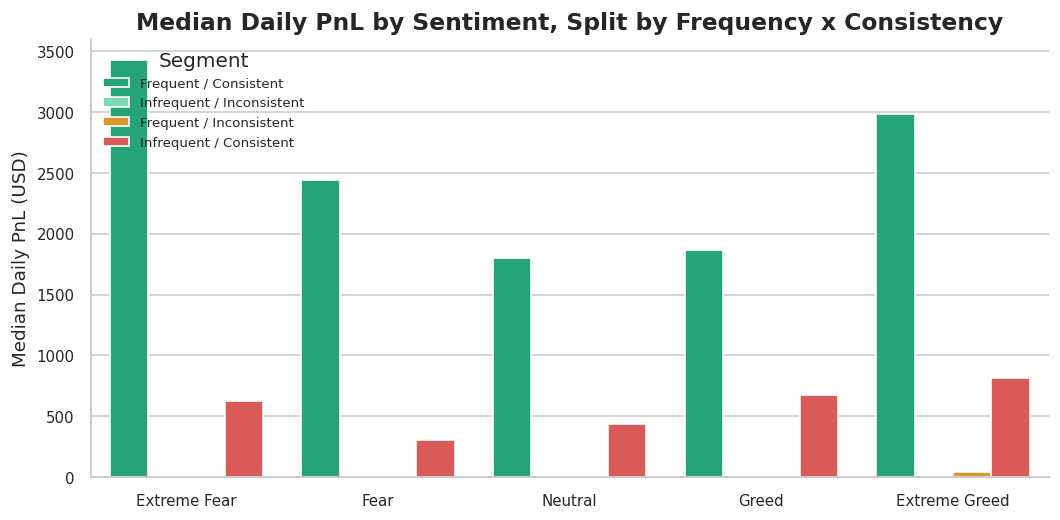

In [3]:
by_sentiment_segment = (
    merged.groupby(['segment', 'classification'])['daily_pnl']
    .median()
    .reset_index()
)

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
by_sentiment_segment['classification'] = pd.Categorical(by_sentiment_segment['classification'], categories=order, ordered=True)
by_sentiment_segment = by_sentiment_segment.sort_values('classification')

plt.figure(figsize=(9, 4.5))
ax = sns.barplot(
    data=by_sentiment_segment,
    x="classification", y="daily_pnl", hue="segment",
    palette=["#10B981", "#6EE7B7", "#F59E0B", "#EF4444"]
)
plt.title("Median Daily PnL by Sentiment, Split by Frequency x Consistency")
plt.xlabel("")
plt.ylabel("Median Daily PnL (USD)")
plt.legend(title="Segment", frameon=False, loc="upper left", fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig("chart4_combined_segment.png", bbox_inches="tight")
plt.show()

### Finding

Four segments, sorted by median daily PnL:

| Segment | Median PnL | Mean PnL | Account-days |
|---|---|---|---|
| Frequent / Consistent | **$2,444** | $12,895 | 688 |
| Infrequent / Consistent | $548 | $3,345 | 481 |
| Frequent / Inconsistent | $0 | **–$108** | 478 |
| Infrequent / Inconsistent | $0 | –$252 | 693 |

**Consistency, not frequency, is what separates the profitable segments from the flat ones.**
"Infrequent / Consistent" traders — who trade less often but win at an above-median rate —
still land at a solidly positive $548 median. "Frequent / Inconsistent" traders — who trade a
lot but don't win enough — average a **negative mean** and a $0 median, no better than doing
nothing. Trading often is not, by itself, a signal of skill.

### Recommendation

Don't build a single sentiment-driven signal for the whole trader base. Instead:

1. **Score every account by trailing win rate** (e.g., a rolling 30-day win rate versus the
   platform median) before applying any sentiment-based rule.
2. **Only apply sentiment-tilted plays — like leaning into Extreme Greed or trimming exposure
   in Fear — to accounts already in the "Consistent" half.** For "Inconsistent" accounts,
   sentiment signals are unlikely to move them off breakeven; the resources are better spent on
   trade-selection/execution coaching or tighter risk limits than on sentiment timing.
3. Frequency can still be used as a secondary tiebreaker (Frequent/Consistent clearly
   outperforms Infrequent/Consistent), but it should never be used as a stand-alone proxy for
   skill — Frequent/Inconsistent is the platform's worst-performing segment by mean PnL.

**Caveat:** win rate and trade count are both computed over the same historical window used to
evaluate them, so this is descriptive segmentation, not a validated predictive model — it
would need an out-of-sample or rolling-window check before being used to gate live capital.

## Strategy 2: Size positions to sentiment-conditioned tail risk, not sentiment-conditioned average return

Q1 showed Fear's high mean is driven by outliers. Here that's made explicit by comparing the
mean/median gap and spread of daily PnL across sentiment categories.

In [5]:
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

dispersion = merged.groupby('classification')['daily_pnl'].agg(
    mean='mean', median='median', std='std', iqr=iqr
)
dispersion['mean_to_median'] = dispersion['mean'] / dispersion['median']
dispersion = dispersion.reindex(order).round(1)
dispersion

,mean,median,std,iqr,mean_to_median
classification,,,,,
Extreme Fear,4619.4,218.4,29534.8,3381.3,21.2
Fear,5328.8,107.9,31659.8,1807.1,49.4
Neutral,3438.6,167.6,17447.9,1322.0,20.5
Greed,3318.1,158.2,30599.0,1319.2,21.0
Extreme Greed,5161.9,418.3,27496.9,2385.4,12.3


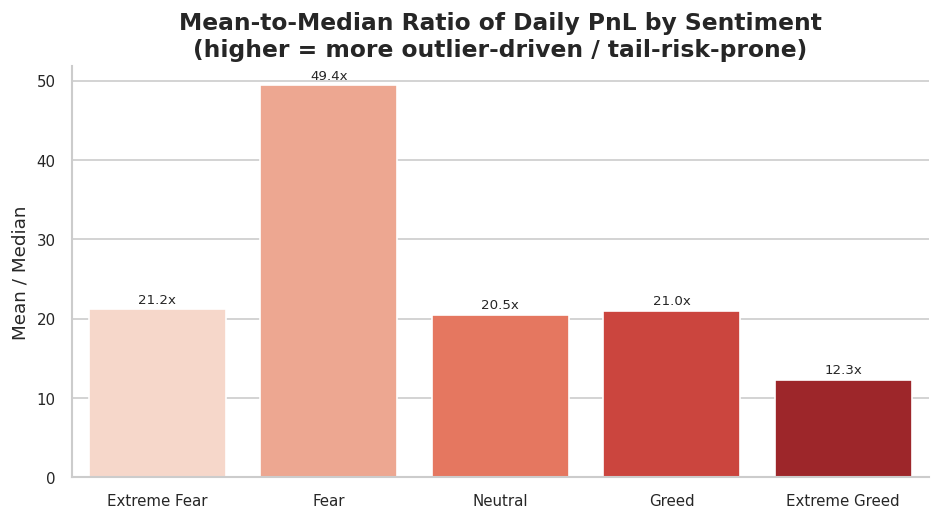

In [6]:
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=dispersion.reset_index(),
    x="classification", y="mean_to_median",
    order=order, hue="classification", palette="Reds", legend=False
)
plt.title("Mean-to-Median Ratio of Daily PnL by Sentiment\n(higher = more outlier-driven / tail-risk-prone)")
plt.xlabel("")
plt.ylabel("Mean / Median")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1fx", fontsize=8, padding=2)
sns.despine()
plt.tight_layout()
plt.savefig("chart5_tail_risk_ratio.png", bbox_inches="tight")
plt.show()

### Finding

| Sentiment | Median PnL | Mean PnL | Std Dev | Mean/Median |
|---|---|---|---|---|
| Extreme Fear | $218 | $4,619 | $29,535 | 21.2x |
| Fear | $108 | $5,329 | $31,660 | **49.4x** |
| Neutral | $168 | $3,439 | $17,448 | 20.5x |
| Greed | $158 | $3,318 | $30,599 | 21.0x |
| Extreme Greed | **$418** | $5,162 | $27,497 | 12.3x |

Fear is the most outlier-driven regime by far — its mean is **49x** its median, roughly double
every other category, and its standard deviation ($31.7k) is the highest on the table despite
having the *lowest* typical (median) outcome of any sentiment bucket. Extreme Greed is the
opposite case: it has the highest median ($418) *and* the lowest mean/median ratio (12.3x),
making it the most "typical-outcome-representative" — and arguably most reliably tradeable —
regime in the dataset.

### Recommendation

Use sentiment as a **position-sizing throttle**, not a directional signal:

1. **Reduce standard position size during Fear and Extreme Fear** (e.g., a fixed haircut such
   as 25–30% off standard size). The typical account-day outcome in Fear is the weakest in the
   dataset (median $108); sizing up here is effectively betting on being one of the rare large
   winners pulling up the mean, which is a lottery-ticket bet, not a repeatable edge.
2. **Allow standard-to-slightly-elevated sizing during Extreme Greed**, where the median outcome
   is both the highest and the most representative of what a typical account-day actually looks
   like (lowest mean/median ratio).
3. Treat Neutral and Greed as the baseline/default sizing regime — both sit in the middle of the
   table on every measure.

This is a risk-management rule, deliberately decoupled from Strategy 1's trader-quality gate —
Strategy 1 decides *who* gets a sentiment-based signal at all; Strategy 2 decides *how big* any
position should be once sentiment is factored in.

**Caveat:** std/IQR here are computed on daily_pnl in raw dollars, which is itself a function of
each account's typical trade size — the ratios are not risk-normalized per account. A production
version should size relative to each account's own historical volatility, not just the platform-wide
distribution.

## Summary

| | Strategy 1: Consistency Gate | Strategy 2: Sentiment-Conditioned Sizing |
|---|---|---|
| **Question it answers** | *Whose* trades should sentiment signals be applied to? | *How large* should a position be, given the sentiment regime? |
| **Core evidence** | Frequent/Inconsistent traders: $0 median, negative mean PnL, despite high activity | Fear: 49x mean/median ratio and highest std dev, lowest median |
| **Rule** | Apply sentiment-based plays only to above-median win-rate accounts | Cut size ~25–30% in Fear/Extreme Fear; standard-to-slightly-elevated in Extreme Greed |
| **Depends on** | Q3 segmentation | Q1 mean/median finding |

## Limitations

- All findings are **correlational**, from a single platform's ~32 accounts over a ~2-year
  window (2023-05-01 to 2025-05-01) — not causal, and not necessarily generalizable to other
  venues or market regimes.
- No transaction costs, funding rates, or slippage are modeled; `Closed PnL` is used as-is.
- Segments (trader_type, consistency_type) are built on the *same* historical window they're
  evaluated against — a real deployment should validate on a held-out period.
- Fear/Greed classification is a market-wide daily label; it says nothing about the specific
  asset(s) each account was trading that day.

## Part C: Actionable Output

### Strategy 1: Target sentiment-based signals only at frequent, consistent traders

Since infrequent and inconsistent traders show flat, near-zero median PnL 
regardless of sentiment, any sentiment-driven trading rule (e.g., "increase 
activity during Fear") should be scoped to traders who already demonstrate 
above-median frequency and win rate. For these traders, Extreme Greed shows 
the strongest median PnL (1,522), suggesting increased position sizing or 
trade frequency during Extreme Greed periods for this segment specifically.

### Strategy 2: Treat Fear-day performance metrics with caution — use median, not mean

Fear days show the largest gap between mean and median PnL of any sentiment 
category (mean 5,329 vs median 108), indicating performance during Fear is 
driven by a small number of outlier accounts rather than broad-based gains. 
A rule of thumb: "During Fear days, do not scale up position size based on 
average PnL figures — the typical trader does not replicate the outlier gains 
that inflate the average." Risk management during Fear periods should assume 
median-level outcomes, not mean-level outcomes.